# Sampling edges of graphs

In [14]:
def sample_graph_edges(G,k='default',labels_matter=False,draw=False,tabulate=true,vertex_labels_=False,edge_labels_=False,vertex_size_=10,figsize_=2):
    E=Set(G.edges())
    V=G.vertices()
    L=[]
    for s in E.subsets():
        if k=='default' or s.cardinality()==k:
            H=Graph()
            H.allow_multiple_edges(true)
            H.add_edges( s )
            edge_label_mset=[]
            for e in H.edges():
                H.delete_edge(e) # need to delete and add in order to
                if labels_matter:
                    label=e[2][0];
                    H.add_edge(e[0],e[1],label) # change labels of multiedges
                    if label:
                        edge_label_mset.append(label)
                else:
                    H.add_edge(e[0],e[1]) # None label
            Hcl=H.canonical_label()
            L.append((Hcl.copy(immutable=True),tuple(sorted(edge_label_mset))))
    Luniq=list(Set(L))
    if labels_matter: # then sort them before sorting by number of edges
        labels = [ tup[1] for tup in Luniq ]
        P = Permutation([labels.index(x)+1 for x in sorted(labels)])
        Luniq=P.action(Luniq)
    Lsorted=[]
    for size in range(G.size()+1):
        for i in range(len(Luniq)):
            if size==(Luniq[i][0]).size(): # 0th element is graph, 1st is set of edge labels
                Lsorted.append(Luniq[i])
    Csorted=[]
    Esorted=[]
    for H in Lsorted:
        c=L.count(H)
        e=H[0].size()
        Csorted.append(c)
        if labels_matter and H[1]:
            Esorted.append(H[1])
        else:
            Esorted.append(e)
        if draw:
                edge_labels_ = edge_labels_ or labels_matter
                H[0].show(figsize=figsize_,vertex_labels=vertex_labels_,vertex_size=vertex_size_,\
                          edge_labels=edge_labels_,title='Size=%s, Count=%s' %(e,c))
                #print(H[0].edges(),H[1])
    if tabulate:
        print('Isomorphism classes:')
        print(table([Esorted, Csorted]))
    return Esorted,Csorted

In [15]:
def add_multiedge(G,k=1,draw=false,vertex_labels_=false,edge_labels_=false,vertex_size_=10,figsize_=5):
    G.allow_multiple_edges(true)
    for e in G.edges():
        if not G.edge_label(e[0],e[1]):
            G.set_edge_label(e[0],e[1],0)
            for i in range(1,k+1):
                G.add_edge(e[0],e[1],i) # distinct labels
        else:
            orig_label=G.edge_label(e[0],e[1])
            G.set_edge_label(e[0],e[1],(orig_label[0],0)) # edge label is tuple
            for i in range(1,k+1):
                G.add_edge(e[0],e[1],(orig_label[0],i)) # distinct labels
    if draw:
        G.show(figsize=figsize_,vertex_labels=vertex_labels_,vertex_size=vertex_size_,edge_labels=edge_labels_)
    return G

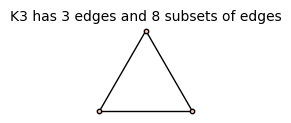

Ways to choose:   1   3   3   1 

Isomorphism classes:
  0   1   2   3
  1   3   3   1


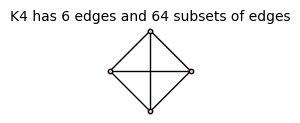

Ways to choose:   1   6   15   20   15   6   1 

Isomorphism classes:
  0   1   2    2   3   3    3   4   4    5   6
  1   6   12   3   4   12   4   3   12   6   1


In [16]:
vertex_labels_=false
vertex_size_=10
figsize_=2
nmin=3
nmax=4
for n in range(nmin,nmax+1):
    Kn = graphs.CompleteGraph(n)
    e = binomial(n,2)
    Kn.show(figsize=figsize_,vertex_labels=vertex_labels_,vertex_size=vertex_size_,title='K%s has %s edges and %s subsets of edges' %(n,e,2^e))
    e_choose_k=[]
    for k in range(e+1):
        e_choose_k.append(binomial(e,k))
    print('Ways to choose:',table(e_choose_k),'\n')
    sample_graph_edges(graphs.CompleteGraph(n),draw=false)

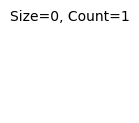

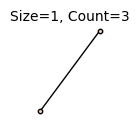

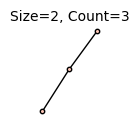

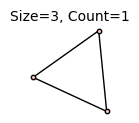

Isomorphism classes:
  0   1   2   3
  1   3   3   1


In [17]:
sample_graph_edges(graphs.CompleteGraph(3),draw=true);

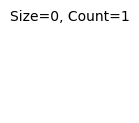

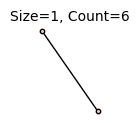

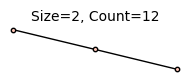

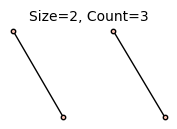

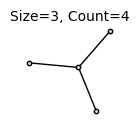

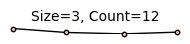

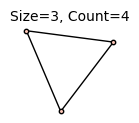

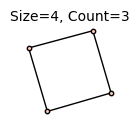

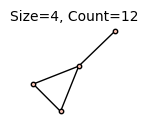

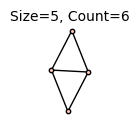

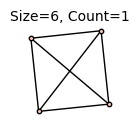

Isomorphism classes:
  0   1   2    2   3   3    3   4   4    5   6
  1   6   12   3   4   12   4   3   12   6   1


In [18]:
sample_graph_edges(graphs.CompleteGraph(4),draw=true);

In [19]:
sample_graph_edges(graphs.CompleteGraph(5));

Isomorphism classes:
  0   1    2    2    3    3    3    3    4    4    4    4    4   4    5    5    5    5    5    5    6    6    6    6   6    6    7    7    7    7    8    8    9    10
  1   10   30   15   20   60   10   30   60   60   15   60   5   10   60   30   60   30   12   60   60   60   60   5   15   10   60   30   10   20   30   15   10   1


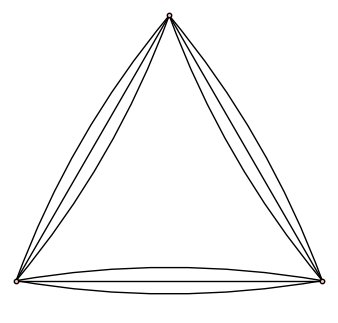

[(0, 1, (None, 0)), (0, 1, (None, 1)), (0, 1, (None, 2)), (0, 2, (None, 0)), (0, 2, (None, 1)), (0, 2, (None, 2)), (1, 2, (None, 0)), (1, 2, (None, 1)), (1, 2, (None, 2))]

In [20]:
G=graphs.CompleteGraph(3)
G=add_multiedge(G,2,draw=true)
G.edges()

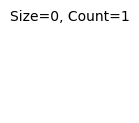

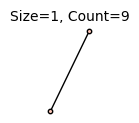

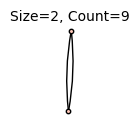

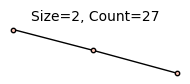

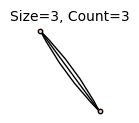

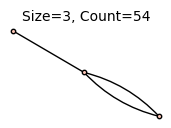

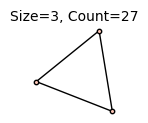

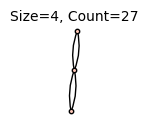

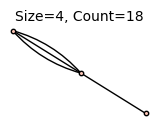

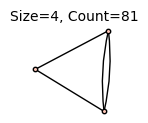

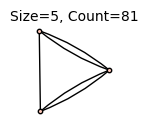

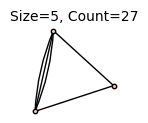

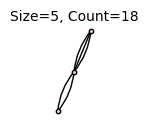

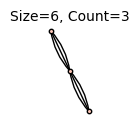

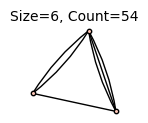

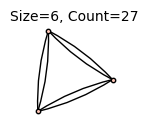

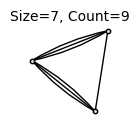

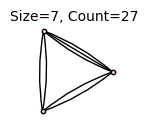

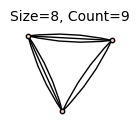

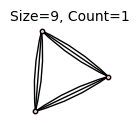

Isomorphism classes:
  0   1   2   2    3   3    3    4    4    4    5    5    5    6   6    6    7   7    8   9
  1   9   9   27   3   54   27   27   18   81   81   27   18   3   54   27   9   27   9   1


In [21]:
sample_graph_edges(G,draw=true);

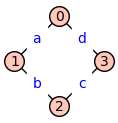

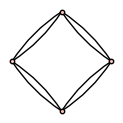

[(0, 1, ('a', 0)), (0, 1, ('a', 1)), (0, 3, ('d', 0)), (0, 3, ('d', 1)), (1, 2, ('b', 0)), (1, 2, ('b', 1)), (2, 3, ('c', 0)), (2, 3, ('c', 1))]

In [22]:
G=graphs.CycleGraph(4)
G.set_edge_label(0,1,'a')
G.set_edge_label(1,2,'b')
G.set_edge_label(2,3,'c')
G.set_edge_label(0,3,'d')
G.show(figsize=2,edge_labels=true)
G=add_multiedge(G,1,draw=true,figsize_=2)
G.edges()

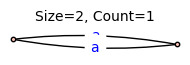

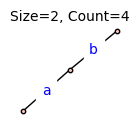

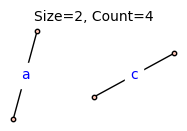

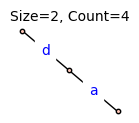

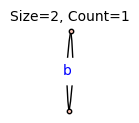

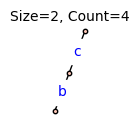

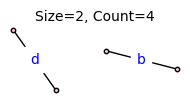

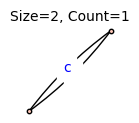

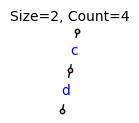

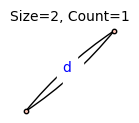

Isomorphism classes:
  ('a', 'a')   ('a', 'b')   ('a', 'c')   ('a', 'd')   ('b', 'b')   ('b', 'c')   ('b', 'd')   ('c', 'c')   ('c', 'd')   ('d', 'd')
  1            4            4            4            1            4            4            1            4            1


In [23]:
sample_graph_edges(G,2,labels_matter=true,draw=true);

In [24]:
sample_graph_edges(G,3);

Isomorphism classes:
  3    3    3
  32   16   8


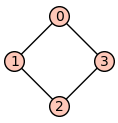

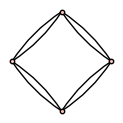

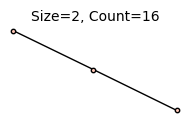

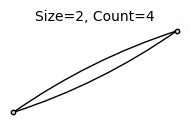

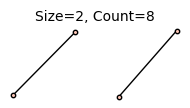

Isomorphism classes:
  2    2   2
  16   4   8


In [25]:
G=graphs.CycleGraph(4)
G.show(figsize=2)
G=add_multiedge(G,1,draw=true,figsize_=2)
G.edges()
sample_graph_edges(G,2,draw=true);

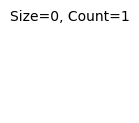

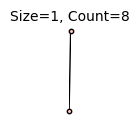

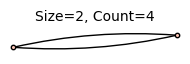

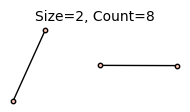

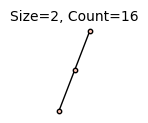

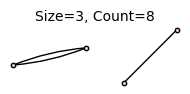

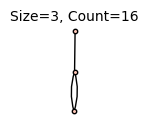

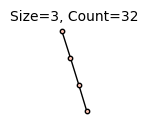

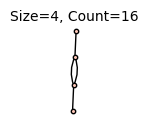

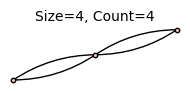

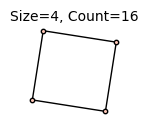

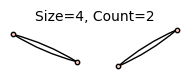

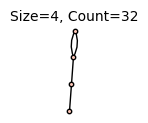

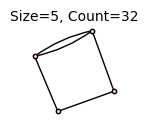

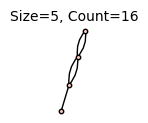

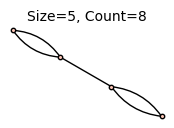

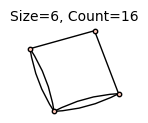

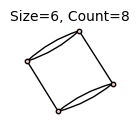

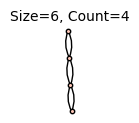

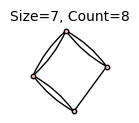

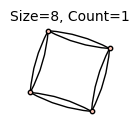

Isomorphism classes:
  0   1   2   2   2    3   3    3    4    4   4    4   4    5    5    5   6    6   6   7   8
  1   8   4   8   16   8   16   32   16   4   16   2   32   32   16   8   16   8   4   8   1


In [26]:
sample_graph_edges(G,draw=true);

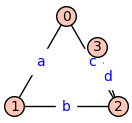

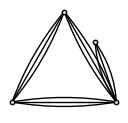

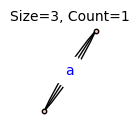

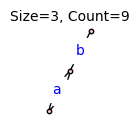

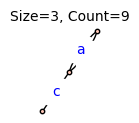

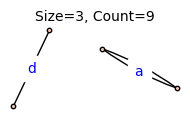

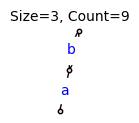

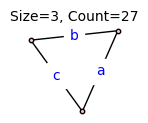

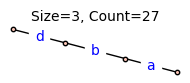

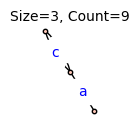

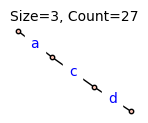

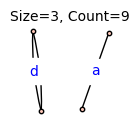

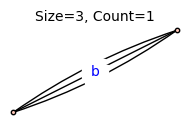

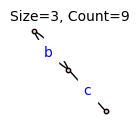

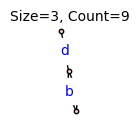

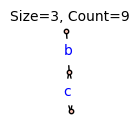

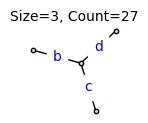

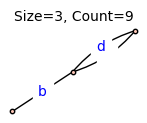

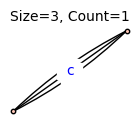

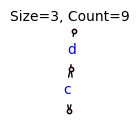

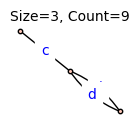

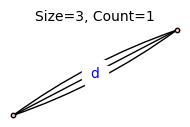

Isomorphism classes:
  ('a', 'a', 'a')   ('a', 'a', 'b')   ('a', 'a', 'c')   ('a', 'a', 'd')   ('a', 'b', 'b')   ('a', 'b', 'c')   ('a', 'b', 'd')   ('a', 'c', 'c')   ('a', 'c', 'd')   ('a', 'd', 'd')   ('b', 'b', 'b')   ('b', 'b', 'c')   ('b', 'b', 'd')   ('b', 'c', 'c')   ('b', 'c', 'd')   ('b', 'd', 'd')   ('c', 'c', 'c')   ('c', 'c', 'd')   ('c', 'd', 'd')   ('d', 'd', 'd')
  1                 9                 9                 9                 9                 27                27                9                 27                9                 1                 9                 9                 9                 27                9                 1                 9                 9                 1


In [27]:
G=graphs.CycleGraph(3)
G.set_edge_label(0,1,'a')
G.set_edge_label(1,2,'b')
G.set_edge_label(0,2,'c')
G.add_edge(2,3,'d')
G.show(figsize=2,edge_labels=true)
G=add_multiedge(G,2,draw=true,figsize_=2)
sample_graph_edges(G,3,labels_matter=true,draw=true);